In [ ]:
from perovskite.data import load_features_and_meta, make_split

# SOAP features + reduced metadata (target y)
X, df_meta = load_features_and_meta("soap")
y = df_meta["is_metal"].values  # target vector
print("X:", X.shape, " df_meta:", df_meta.shape)
df_meta.head()

In [ ]:
X_train, X_test, y_train, y_test = make_split(X, y)
print("X_train Form:", X_train.shape)

In [3]:
# Direkt splitten und trainieren!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train Form:", X_train.shape)  # Bereit für Random Forest, Ridge Regression etc.

X_train Form: (6400, 48870)


## Anaylse Dataset

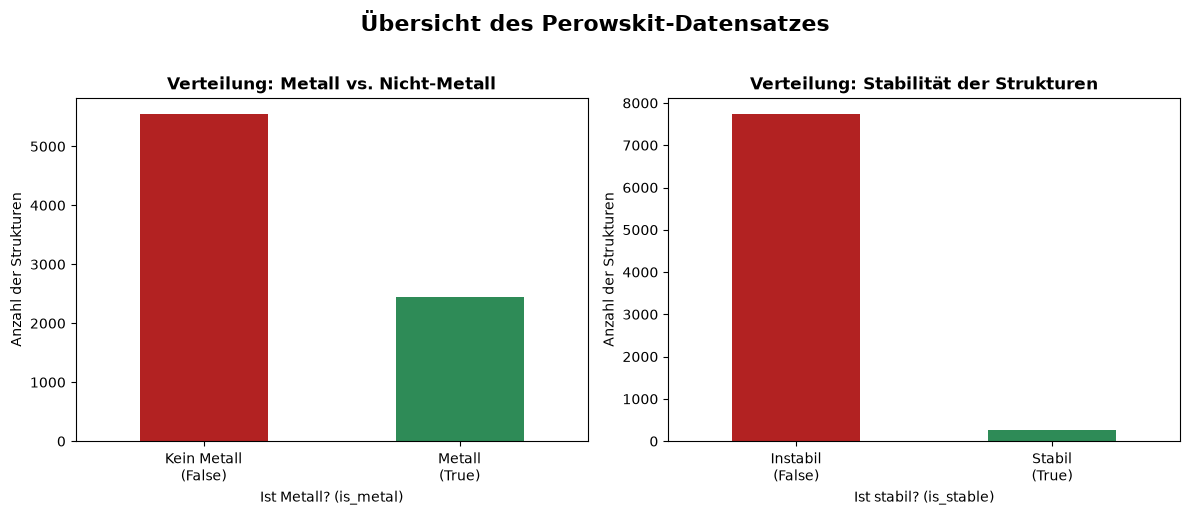

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Häufigkeiten für die gewünschten Spalten zählen
counts_metal = df_meta["is_metal"].value_counts()
# Falls du eine zweite Spalte wie 'is_stable' hast, zählen wir die hier auch:
counts_stable = df_meta["is_stable"].value_counts() 

# 2. Subplots initialisieren: 1 Zeile, 2 Spalten
# fig ist die gesamte Grafik, ax ist eine Liste mit den einzelnen Achsen: ax[0] und ax[1]
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- LINKER PLOT (Index 0) ---
# Mit ax=ax[0] sagen wir Pandas, dass es links zeichnen soll
counts_metal.plot(kind="bar", color=["firebrick", "seagreen"], ax=ax[0])
ax[0].set_title("Verteilung: Metall vs. Nicht-Metall", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Ist Metall? (is_metal)")
ax[0].set_ylabel("Anzahl der Strukturen")
ax[0].set_xticklabels(["Kein Metall\n(False)", "Metall\n(True)"], rotation=0)

# --- RECHTER PLOT (Index 1) ---
# Mit ax=ax[1] sagen wir Pandas, dass es rechts zeichnen soll
counts_stable.plot(kind="bar", color=["firebrick", "seagreen"], ax=ax[1])
ax[1].set_title("Verteilung: Stabilität der Strukturen", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Ist stabil? (is_stable)")
ax[1].set_ylabel("Anzahl der Strukturen")
ax[1].set_xticklabels(["Instabil\n(False)", "Stabil\n(True)"], rotation=0)

# Gesamt-Titel über beide Plots hinweg (optional)
fig.suptitle("Übersicht des Perowskit-Datensatzes", fontsize=16, fontweight="bold", y=1.02)

# Grafik anzeigen (tight_layout sorgt dafür, dass sich Achsenbeschriftungen nicht überschneiden)
plt.tight_layout()
plt.show()

## Support Vector Machines

## Feature Scaling (kann stark die SVM beeinflussen!)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import numpy as np
from sklearn.svm import SVC  # <--- NEUER IMPORT für die Support Vector Machine
from sklearn.model_selection import GridSearchCV

# 1. Das Basis-Modell definieren
# class_weight='balanced' fängt dein Klassenungleichgewicht ab
# cache_size=1000 erhöht den RAM-Speicher (in MB) für das Training, was es bei großen Datensätzen beschleunigt
svm_model = SVC(class_weight="balanced", random_state=42, cache_size=1000)

# 2. Den Suchraum (Grid) festlegen
# WICHTIG: SVMs reagieren sehr empfindlich auf C und gamma.
# Weil dein SOAP-Deskriptor mit ca. 50.000 Spalten riesig ist, starten wir mit dem schnellen 'linear' Kernel
# und dem standardmäßigen 'rbf' Kernel.
param_grid_svm = {
    "C": [0.1, 1, 10],  # Regulations-Parameter (Straftoleranz für Fehlklassifikationen)
    "kernel": ["linear", "rbf"],  # 'linear' ist oft sehr stark und schnell bei extrem vielen Features (breiten Daten)
    "gamma": ["scale", "auto"],  # Kernel-Koeffizient (nur relevant für 'rbf')
}

# 3. Grid Search initialisieren
# cv=3 und scoring='f1_macro' bleiben exakt gleich wie bei deinem Random Forest
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=3,
    scoring="f1_macro",
    verbose=2,  # Zeigt dir den Fortschritt live an
    n_jobs=-1,  # Nutzt alle CPU-Kerne, um die Kombinationen parallel zu berechnen
)

# 4. Suche starten
print("Starte Grid Search für die Support Vector Machine...")
print(
    "Hinweis: Das kann bei 50.000 SOAP-Features und 8.000 Strukturen ein Weilchen dauern."
)
grid_search_svm.fit(X_train_scaled, y_train)

# 5. Bestes Ergebnis anzeigen
print("\n=== SVM GRID SEARCH BEENDET ===")
print(f"Bester F1-Macro-Score: {grid_search_svm.best_score_:.2f}")
print("Beste Parameter-Kombination:")
print(grid_search_svm.best_params_)

# Das beste SVM-Modell direkt für Vorhersagen nutzen
best_svm_model = grid_search_svm.best_estimator_

Starte Grid Search für die Support Vector Machine...
Hinweis: Das kann bei 50.000 SOAP-Features und 8.000 Strukturen ein Weilchen dauern.
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC  # <--- Viel schneller als das normale SVC!

# =====================================================================
# 1. WICHTIG: Daten skalieren (Ohne das konvergiert eine SVM bei SOAP nie!)
# =====================================================================

# =====================================================================
# 2. Das vielversprechende SVM-Modell definieren
# =====================================================================
# - LinearSVC ist extrem optimiert für "breite" Daten (viele Spalten).
# - class_weight='balanced' fängt dein Klassenungleichgewicht ab.
# - verbose=1 zeigt dir den internen Trainingsfortschritt (Iterationen) live an!
# - max_iter=2000 gibt dem Modell genug Zeit zum Lernen.
svm_fast = LinearSVC(
    C=0.5,  # Ein solider, leicht regulierter Standardwert
    class_weight="balanced",
    dual=False,  # <--- WICHTIG: dual=False ist extrem viel schneller, wenn n_samples < n_features (8.000 < 50.000)
    verbose=1,  # <--- HIERMIT siehst du den Live-Fortschritt im Terminal!
    random_state=42,
    max_iter=2000,
)

# =====================================================================
# 3. Modell trainieren (mit Live-Fortschritt)
# =====================================================================
print("\nStarte SVM-Training...")
svm_fast.fit(X_train_scaled, y_train)
print("Training erfolgreich beendet!")

# =====================================================================
# 4. Evaluierung
# =====================================================================
y_pred = svm_fast.predict(X_test_scaled)

print("\nClassification Report für die schnelle SVM:")
print(
    classification_report(
        y_test, y_pred, target_names=["Kein Metall (False)", "Metall (True)"]
    )
)


Starte SVM-Training...
[LibLinear]iter  1 act 2.954e+03 pre 2.919e+03 delta 4.736e-01 f 3.200e+03 |g| 3.185e+04 CG  12
cg reaches trust region boundary
iter  2 act -8.453e+01 pre 1.436e+02 delta 1.829e-01 f 2.461e+02 |g| 2.507e+03 CG  30
cg reaches trust region boundary
iter  2 act 5.430e+01 pre 9.005e+01 delta 1.310e-01 f 2.461e+02 |g| 2.507e+03 CG  12
cg reaches trust region boundary
iter  3 act 5.738e+01 pre 6.827e+01 delta 1.310e-01 f 1.918e+02 |g| 3.233e+03 CG  12
cg reaches trust region boundary
iter  4 act 1.588e+01 pre 3.281e+01 delta 8.707e-02 f 1.344e+02 |g| 1.830e+03 CG  11
cg reaches trust region boundary
iter  5 act 2.163e+01 pre 2.821e+01 delta 8.707e-02 f 1.186e+02 |g| 1.860e+03 CG  11
cg reaches trust region boundary
iter  6 act 9.328e+00 pre 1.501e+01 delta 6.383e-02 f 9.694e+01 |g| 1.310e+03 CG  11
cg reaches trust region boundary
iter  7 act 8.881e+00 pre 1.112e+01 delta 6.383e-02 f 8.761e+01 |g| 9.714e+02 CG  11
cg reaches trust region boundary
iter  8 act 2.476e+0